In [1]:
import pandas as pd 
import numpy  as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

import tensorflow as tf 
from keras.preprocessing.image import load_img
from keras.models import Sequential,Model
from keras.layers import Dense ,Conv2D,Dropout,Flatten,MaxPooling2D,Input

2025-05-01 21:51:57.850678: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746136318.084430      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746136318.155013      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
BASE_DIR='../input/utkface-new/UTKFace/'

In [3]:
image_paths=[]
age_labels=[]
gender_labels=[]
for filename in tqdm(os.listdir(BASE_DIR)):
    image_path=os.path.join(BASE_DIR,filename)
    temp=filename.split('_')
    age=int(temp[0])
    gender=int(temp[1])
    image_paths.append(image_path)
    age_labels.append(age)
    gender_labels.append(gender)

  0%|          | 0/23708 [00:00<?, ?it/s]

In [4]:
df=pd.DataFrame()
df['image'],df['age'],df['gender']=image_paths,age_labels,gender_labels
df.head()

,image,age,gender
0,../input/utkface-new/UTKFace/26_0_2_2017010402...,26,0
1,../input/utkface-new/UTKFace/22_1_1_2017011223...,22,1
2,../input/utkface-new/UTKFace/21_1_3_2017010500...,21,1
3,../input/utkface-new/UTKFace/28_0_0_2017011718...,28,0
4,../input/utkface-new/UTKFace/17_1_4_2017010322...,17,1


In [5]:
gender_dict={0:'Male',1:'Female'}

**Exploratory Data Analysis******

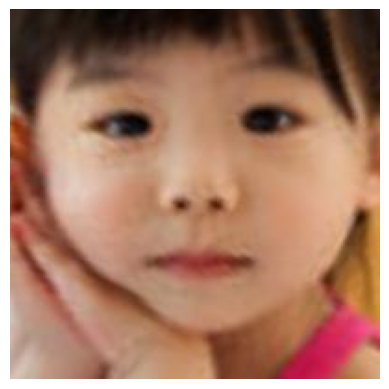

In [6]:
from PIL import Image
img = Image.open(df['image'][100])  # Corrected
plt.axis('off')
plt.imshow(img)
plt.show()  # Recommended for consistent output


<Axes: xlabel='age', ylabel='Density'>

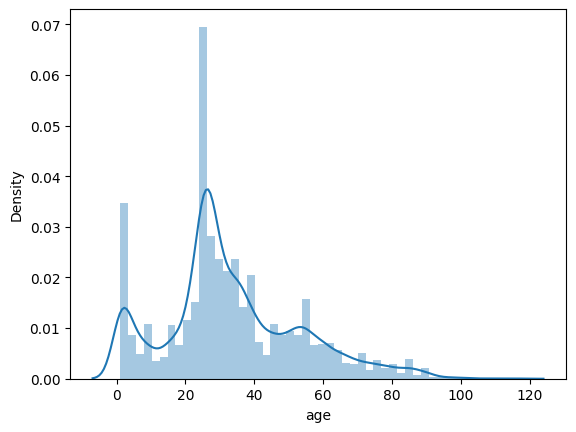

In [7]:
sns.distplot(df['age'])

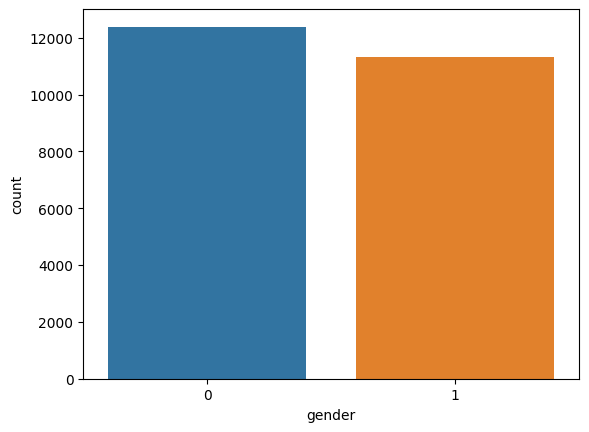

In [8]:
sns.countplot(x='gender', data=df)
plt.show()


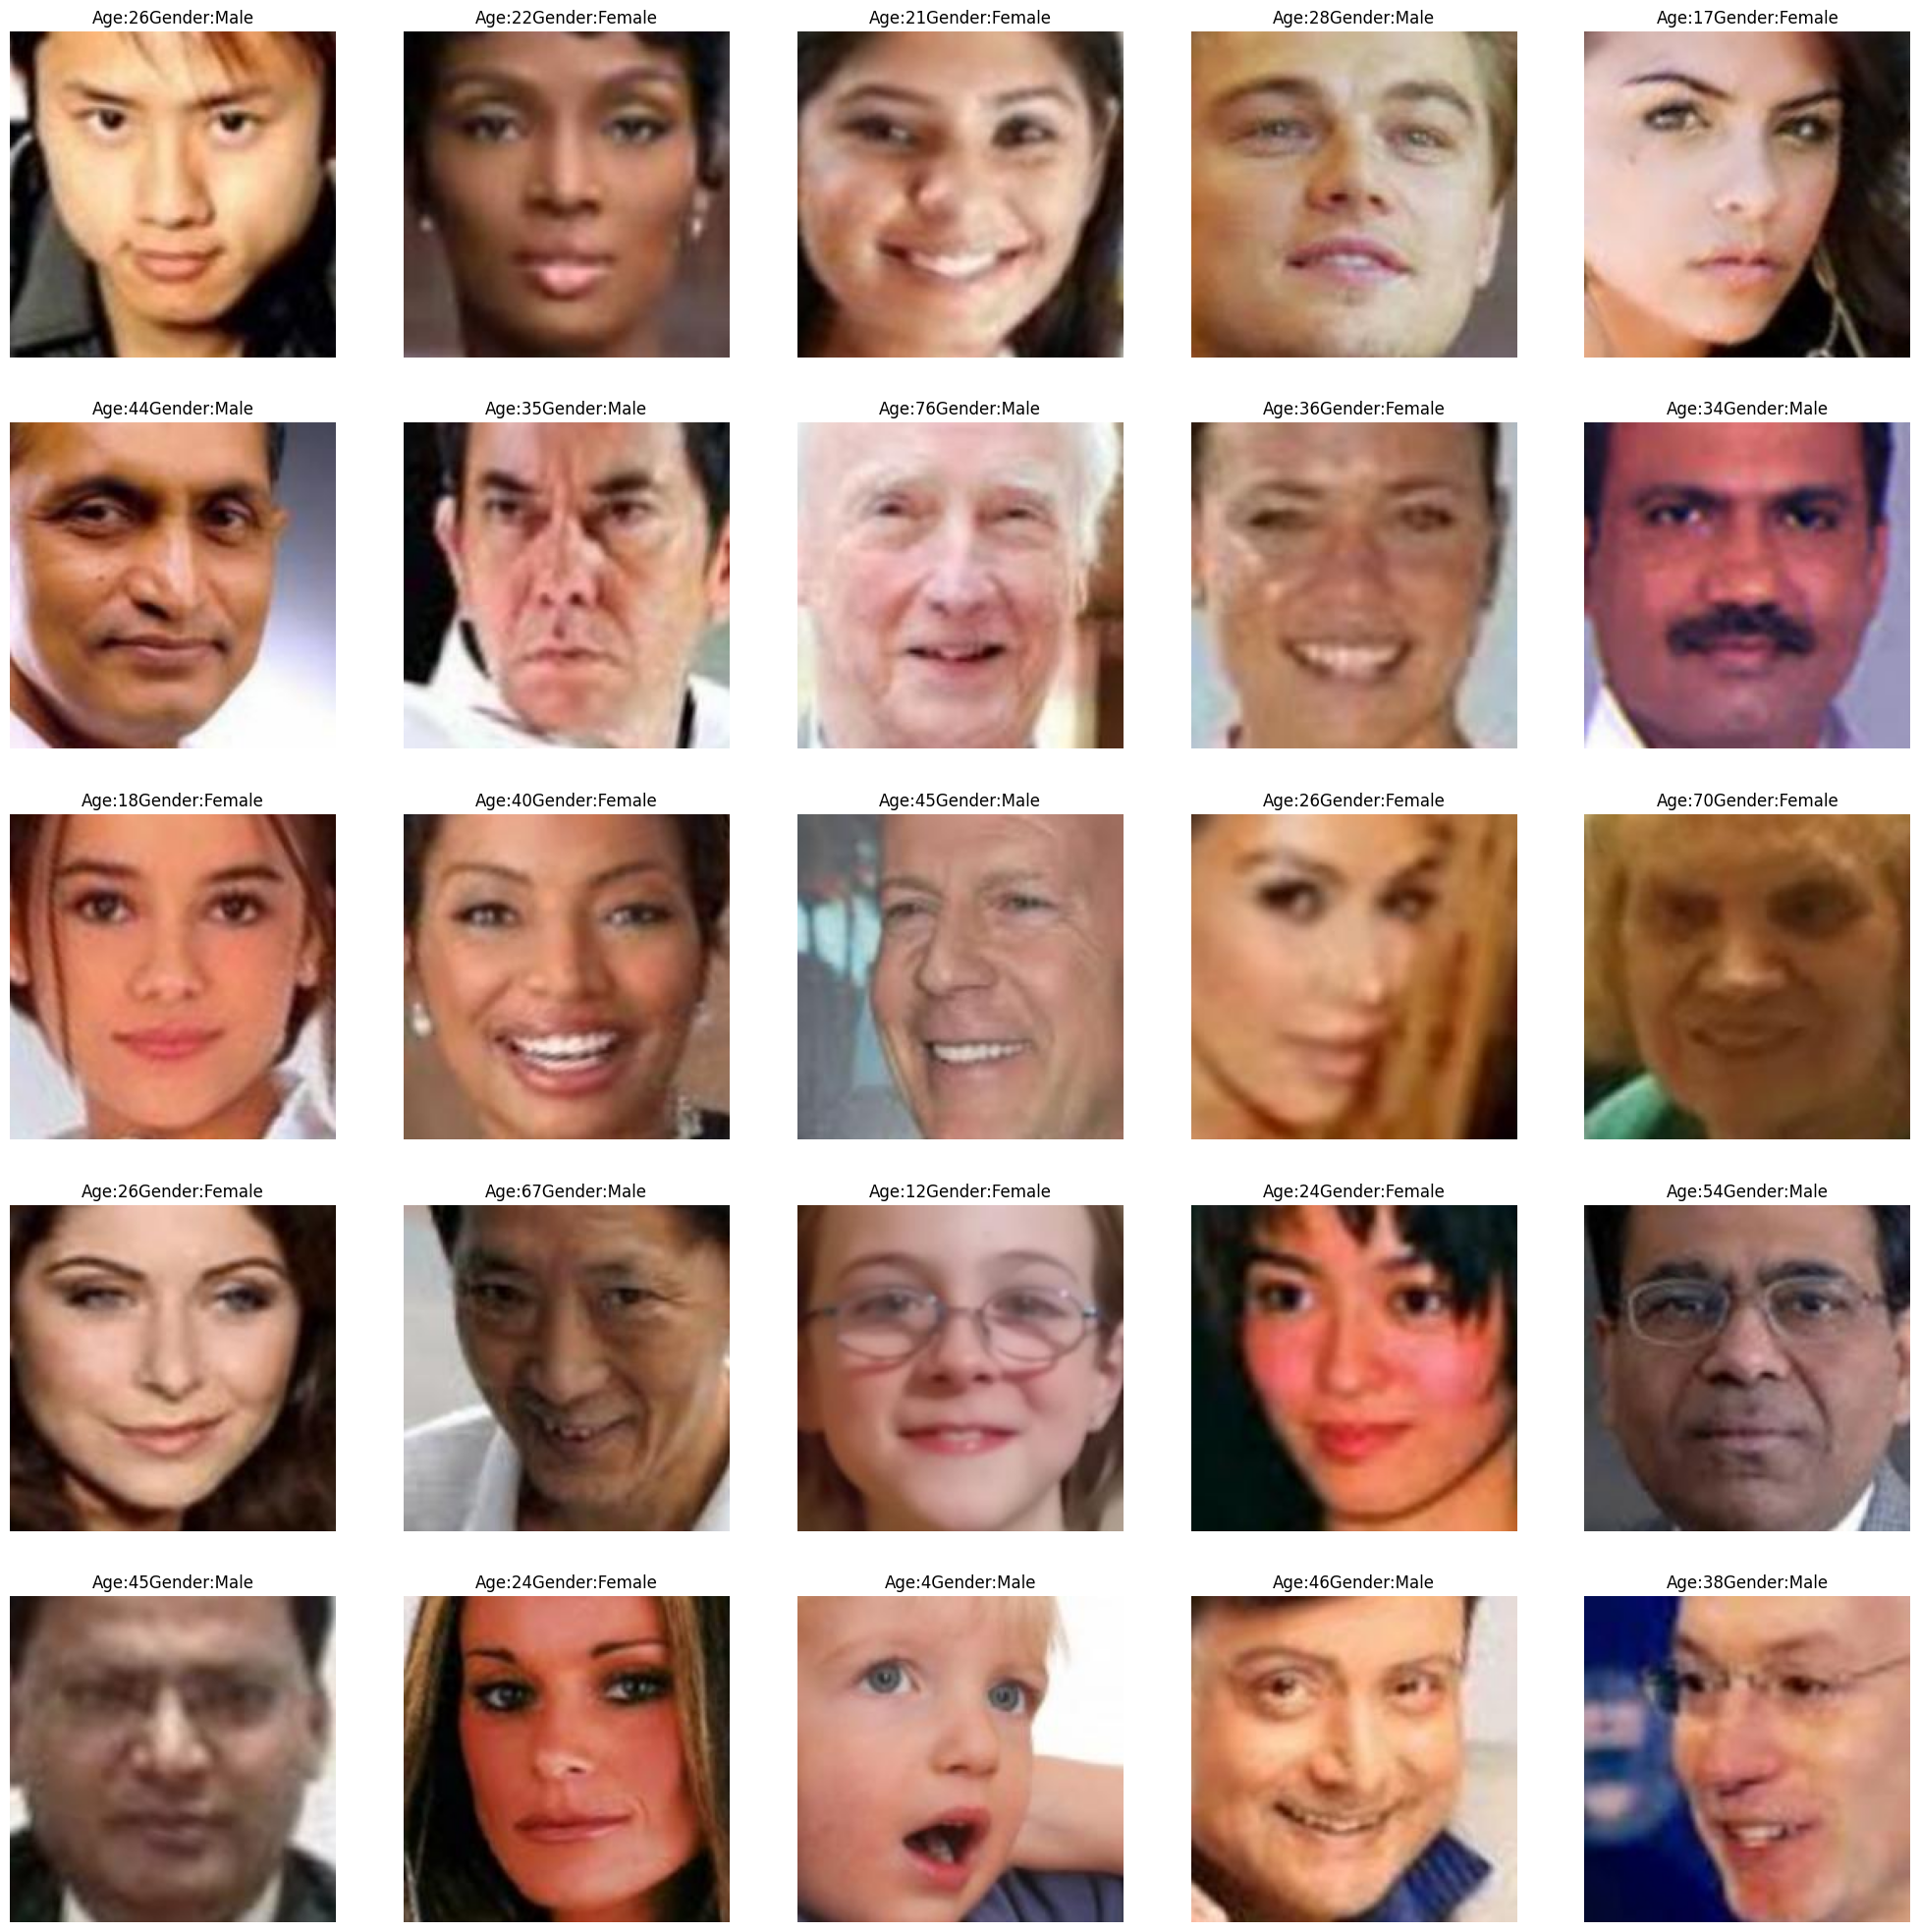

In [9]:
# to display grid of images

plt.figure(figsize=(25, 25))

files=df.iloc[0:25]

for index, file, age, gender in files.itertuples():
    plt.subplot(5, 5, index+1)

    img = load_img(file)

    img = np.array(img)
    

    plt.imshow(img)

    plt.title(f"Age:{age}Gender:{gender_dict[gender]}")
    plt.axis('off')

In [10]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tqdm import tqdm
import numpy as np

def extract_features(images):
    features = []

    for image in tqdm(images):
        img = load_img(image, color_mode='grayscale')  # Use color_mode
        img = img.resize((128, 128), resample=Image.LANCZOS)  # Image resizing
        img = np.array(img)  # Convert to numpy array

        features.append(img)

    features = np.array(features)

    # Ignore this step if using RGB
    features = features.reshape(len(features), 128, 128, 1)

    return features


In [11]:
# Suppose df['images'] contains paths like: ['path/to/img1.jpg', 'path/to/img2.jpg', ...]

X = extract_features(df['image'].tolist())


100%|██████████| 23708/23708 [03:36<00:00, 109.47it/s]


In [12]:
X.shape


(23708, 128, 128, 1)

In [13]:
X=X/255.0

In [14]:
y_gender=np.array(df['gender'])
y_age=np.array(df['age'])

In [15]:
input_shape=(128,128,1)

In [16]:
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Input layer
inputs = Input(shape=input_shape)  # Example: input_shape = (128,128,1)

# Convolutional layers
conv_1 = Conv2D(32, kernel_size=(3, 3), activation='relu')(inputs)
maxp_1 = MaxPooling2D(pool_size=(2, 2))(conv_1)

conv_2 = Conv2D(64, kernel_size=(3, 3), activation='relu')(maxp_1)
maxp_2 = MaxPooling2D(pool_size=(2, 2))(conv_2)

conv_3 = Conv2D(128, kernel_size=(3, 3), activation='relu')(maxp_2)
maxp_3 = MaxPooling2D(pool_size=(2, 2))(conv_3)

conv_4 = Conv2D(256, kernel_size=(3, 3), activation='relu')(maxp_3)
maxp_4 = MaxPooling2D(pool_size=(2, 2))(conv_4)

# Flatten layer
flatten = Flatten()(maxp_4)

# Fully connected (dense) layers
dense_1 = Dense(256, activation='relu')(flatten)
dropout_1 = Dropout(0.3)(dense_1)

dense_2 = Dense(256, activation='relu')(dropout_1)
dropout_2 = Dropout(0.3)(dense_2)

output_1=Dense(1,activation='sigmoid',name='gender_out')(dropout_1)
output_2=Dense(1,activation='relu',name='age_out')(dropout_2)

model=Model(inputs=[inputs],outputs=[output_1,output_2])
model.compile(loss=['binary_crossentropy','mae'],optimizer='adam',metrics=['accuracy','mae'])

I0000 00:00:1746136555.146737      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [17]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 1)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 126, 126, 32)   │            320 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 63, 63, 32)     │              0 │ conv2d[0][0]           │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 61, 61, 64)     │         18,496 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 30, 30, 64)     │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 28, 28, 128)    │         73,856 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 14, 14, 128)    │              0 │ conv2d_2[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 12, 12, 256)    │        295,168 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 6, 6, 256)      │              0 │ conv2d_3[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 9216)           │              0 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 256)            │      2,359,552 │ flatten[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 256)            │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 256)            │         65,792 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 256)            │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gender_out (Dense)        │ (None, 1)              │            257 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ age_out (Dense)           │ (None, 1)              │            257 │ dropout_1[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 2,813,698 (10.73 MB)

 Trainable params: 2,813,698 (10.73 MB)

 Non-trainable params: 0 (0.00 B)

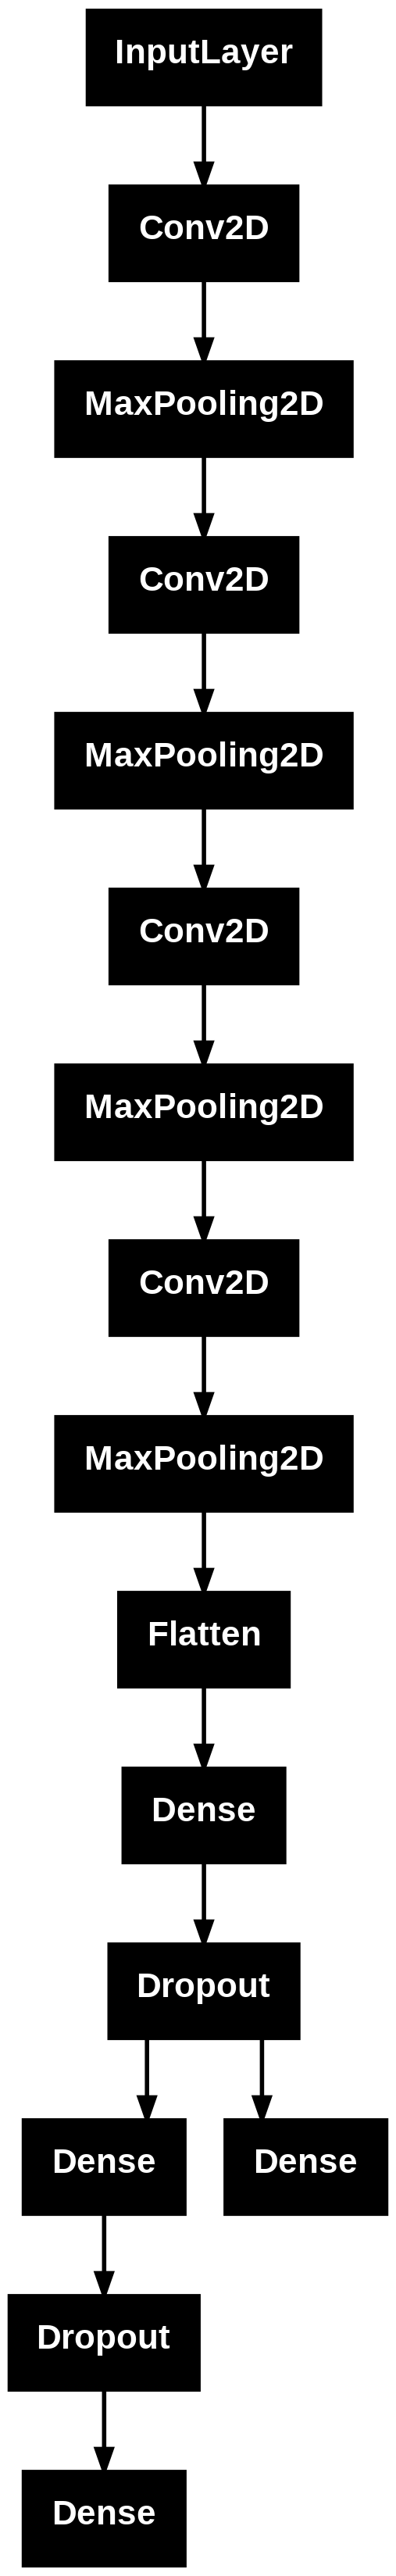

In [18]:
from tensorflow.keras.utils import plot_model
plot_model(model)

In [19]:
# Training
history = model.fit(
    x=X, 
    y=[y_gender, y_age],
    batch_size=32,
    epochs=30,
    validation_split=0.2
)


Epoch 1/30


I0000 00:00:1746136564.202527      97 service.cc:148] XLA service 0x78ec04003450 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746136564.203405      97 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1746136564.654589      97 cuda_dnn.cc:529] Loaded cuDNN version 90300


 16/593 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - age_out_loss: 25.1217 - age_out_mae: 25.1217 - gender_out_accuracy: 0.5048 - gender_out_loss: 1.0067 - loss: 26.1283

I0000 00:00:1746136568.382080      97 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


593/593 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - age_out_loss: 16.6400 - age_out_mae: 16.6400 - gender_out_accuracy: 0.5200 - gender_out_loss: 0.9002 - loss: 17.5403 - val_age_out_loss: 12.1529 - val_age_out_mae: 12.1314 - val_gender_out_accuracy: 0.7071 - val_gender_out_loss: 0.5569 - val_loss: 12.6865
Epoch 2/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - age_out_loss: 11.6352 - age_out_mae: 11.6352 - gender_out_accuracy: 0.7216 - gender_out_loss: 0.5575 - loss: 12.1927 - val_age_out_loss: 9.9582 - val_age_out_mae: 9.9499 - val_gender_out_accuracy: 0.7499 - val_gender_out_loss: 0.5075 - val_loss: 10.4560
Epoch 3/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - age_out_loss: 9.5905 - age_out_mae: 9.5905 - gender_out_accuracy: 0.7601 - gender_out_loss: 0.5148 - loss: 10.1053 - val_age_out_loss: 8.2395 - val_age_out_mae: 8.2639 - val_gender_out_accuracy: 0.7847 - val_gender_out_loss: 0.4615 - val_loss: 8.7254
Epoch 4/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - age_out_loss: 8.7974 - age_ou

[0.5739744901657104, 0.7278814911842346, 0.761256992816925, 0.7850363850593567, 0.8053885698318481, 0.8214172720909119, 0.8364441394805908, 0.844933032989502, 0.8518401384353638, 0.8560581803321838, 0.8667088747024536, 0.8685542345046997, 0.8747231960296631, 0.8782558441162109, 0.8803121447563171, 0.8830011487007141, 0.8825793266296387, 0.8914900422096252, 0.8899610042572021, 0.8918591141700745, 0.8925445675849915, 0.8990825414657593, 0.8970262408256531, 0.903458833694458, 0.9035115242004395, 0.9075714349746704, 0.909733235836029, 0.911736786365509, 0.9123694896697998, 0.9125276803970337]


<Figure size 640x480 with 0 Axes>

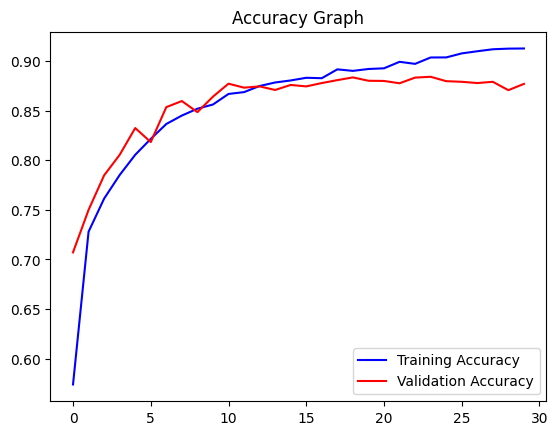

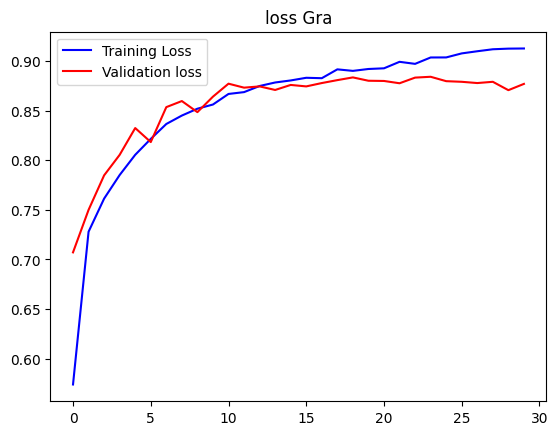

<Figure size 640x480 with 0 Axes>

In [20]:
acc=history.history['gender_out_accuracy']
val_acc=history.history['val_gender_out_accuracy']
epochs=range(len(acc))
plt.plot(epochs,acc,'b',label='Training Accuracy')
plt.plot(epochs,val_acc,'r',label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.figure()
print(acc)

loss=history.history['gender_out_loss']
val_loss=history.history['val_gender_out_loss']

plt.plot(epochs,acc,'b',label='Training Loss')
plt.plot(epochs,val_acc,'r',label='Validation loss')
plt.title('loss Gra')
plt.legend()
plt.figure()

plot results for age


<Figure size 640x480 with 0 Axes>

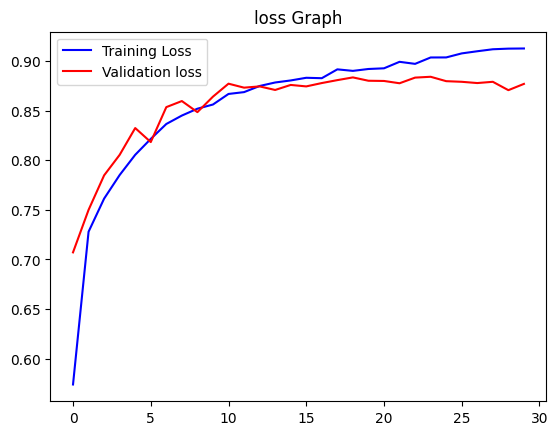

<Figure size 640x480 with 0 Axes>

In [21]:
loss=history.history['age_out_loss']
val_loss=history.history['val_age_out_loss']
epochs=range(len(loss))
plt.plot(epochs,acc,'b',label='Training Loss')
plt.plot(epochs,val_acc,'r',label='Validation loss')
plt.title('loss Graph')
plt.legend()
plt.figure()

original Gender: Female original age; 41
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
predicted Gender Female Predicted Age 37


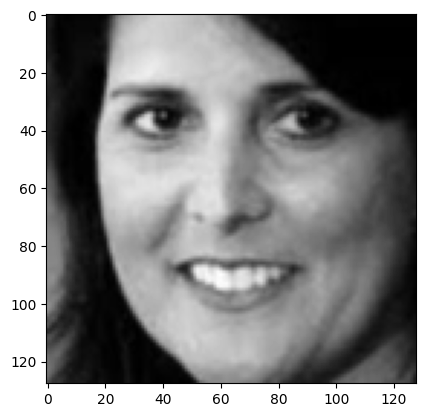

In [29]:
image_index=730
print("original Gender:",gender_dict[y_gender[image_index]],"original age;",y_age[image_index])

pred=model.predict(X[image_index].reshape(1,128,128,1))
pred_gender=gender_dict[round(pred[0][0][0])]
pred_age=round(pred[1][0][0])
print("predicted Gender",pred_gender,"Predicted Age",pred_age)
plt.imshow(X[image_index].reshape(128,128),cmap='gray')